In [59]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

Импорт датасета

In [60]:
df = pd.read_csv("./datasets/_data.csv")

График распределения значений NaN

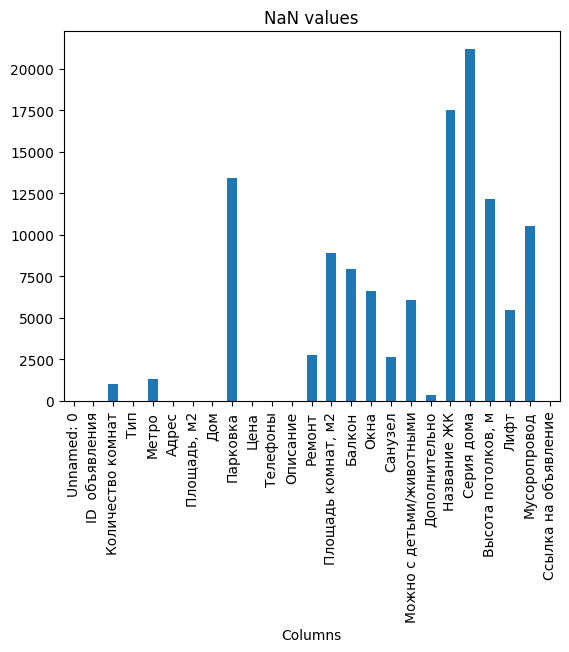

In [61]:
nan = df.isna().sum()
nan.plot(kind='bar')
plt.title("NaN values")
plt.xlabel('Columns')
plt.show()

Процент пустых значений для столбцов

In [62]:
df.isna().mean()

Unnamed: 0                  0.000000
ID  объявления              0.000000
Количество комнат           0.044548
Тип                         0.000000
Метро                       0.056274
Адрес                       0.000000
Площадь, м2                 0.000000
Дом                         0.000000
Парковка                    0.574161
Цена                        0.000000
Телефоны                    0.000000
Описание                    0.000000
Ремонт                      0.117896
Площадь комнат, м2          0.381291
Балкон                      0.341407
Окна                        0.282994
Санузел                     0.114344
Можно с детьми/животными    0.260870
Дополнительно               0.015277
Название ЖК                 0.749743
Серия дома                  0.907438
Высота потолков, м          0.520455
Лифт                        0.235365
Мусоропровод                0.450274
Ссылка на объявление        0.000000
dtype: float64

Очистка и предобработка датафрейма 

In [63]:
#оставляем только количество комнат и убираем лишние слова
def clean_rooms(value):
    
    if pd.isna(value):
        return None
    #первое число в строке
    match = re.search(r'(\d+)', str(value))
    return int(match.group(1)) if match else None

df['Количество комнат'] = df['Количество комнат'].apply(clean_rooms)
df['Количество комнат'] = pd.to_numeric(df['Количество комнат'], errors='coerce').astype('Int64')
df['Количество комнат'] = df['Количество комнат'].fillna(0)


In [64]:
#выделение города из адреса
df[['Город', 'Адрес']]=df['Адрес'].str.split(',', n=1, expand=True)
df['Город']=df['Город'].str.strip()
df['Адрес']=df['Адрес'].str.strip()

# сохранение результата без СПб и Краснодара
df=df[~((df['Город']=='Санкт-Петербург') | (df['Город']=='Краснодарский край'))]
df = df.drop('Город', axis=1)

In [65]:
# Выделение столбцов этаж квартиры, этажность дома, тип дома
df[['этажи', 'тип_дома']] = df['Дом'].str.split(',', n=1, expand=True)
df[['этаж_квартиры', 'этажность_дома']] = df['этажи'].str.split('/', n=1, expand=True)

df['этаж_квартиры'] = df['этаж_квартиры'].str.strip()
df['этажность_дома'] = df['этажность_дома'].str.strip()
df['тип_дома'] = df['тип_дома'].str.strip()

df = df.drop('этажи', axis=1)
df = df.drop('Дом', axis=1)

In [66]:
df.sample()

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Парковка,Цена,Телефоны,...,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление,тип_дома,этаж_квартиры,этажность_дома
22215,22215,273107335,2,Квартира,м. Марьина роща (6 мин пешком),"Октябрьская улица, 91К2",42.0/27.0/7.0,NaN,"55000.0 руб./ За месяц, Залог - 55000 руб., Ко...",+79651663963,...,"Мебель в комнатах, Душевая кабина, Стиральная ...",NaN,II-68-01(II-68-01/16Ю),2.5,NaN,NaN,https://www.cian.ru/rent/flat/273107335,Панельный,14,16


In [67]:
#Приведение лифтов к бинарному значению
df['Лифт'] = df['Лифт'].fillna(0)
df['Лифт'] = df['Лифт'].astype(bool).astype(int)

#Приведение паркинга к бинарному значению
df['Парковка'] = df['Парковка'].fillna(0)
df['Парковка'] = df['Парковка'].astype(bool).astype(int)

#площадь разобъем на три колонки "общую", "жилую" и "кухню"

In [68]:
def split_area(area_str):
    if pd.isna(area_str):
        return pd.Series([None, None, None])
    parts = str(area_str).split('/')
    total = float(parts[0]) if len(parts) > 0 else None
    living = float(parts[1]) if len(parts) > 1 else None
    kitchen = float(parts[2]) if len(parts) > 2 else None
    return pd.Series([total, living, kitchen])
#теперь сама функция
df[['Площадь_общая', 'Площадь_жилая', 'Площадь_кухня']] = df['Площадь, м2'].apply(split_area)

In [69]:
#теперь уберем изначальную колонку площадь и NaN из новых колонок
df = df.drop('Площадь, м2', axis=1)
df.drop('Тип', axis=1, inplace=True)
df.drop('Высота потолков, м', axis=1, inplace=True)
df.drop('Площадь комнат, м2', axis=1, inplace=True)
df.drop('Серия дома', axis=1, inplace=True)
df.drop('Окна', axis=1, inplace=True)
df.drop('Санузел', axis=1, inplace=True)
df.drop('Площадь_кухня', axis=1, inplace=True)

df.drop('Площадь_жилая', axis=1, inplace=True)

In [70]:
#сначала разделим балкон на 2 колонки "Балкон" и "Лоджия" и там где NaN поставим значение 0
def split_categorical_column(df, column_name, categories_dict):
    df_result = df.copy()
    
    for new_col, keyword in categories_dict.items():
        df_result[new_col] = df[column_name].apply(
            lambda x: 1 if pd.notna(x) and keyword.lower() in str(x).lower() else 0
        )
    
    def extract_count(value):
        if pd.isna(value):
            return 0
        match = re.search(r'\((\d+)\)', str(value))
        return int(match.group(1)) if match else 0
    
    df_result[f'{column_name}'] = df[column_name].apply(extract_count)
    
    return df_result

categories = {
    'Балкон': 'балкон',
    'Лоджия': 'лоджия',
}

df = split_categorical_column(df, 'Балкон', categories)

In [71]:
# Удаление из цен лишней информации
price = df['Цена'].apply(lambda x: int(x.split('.')[0]))
df['Цена'] = price

Выявление экстремумов в ценах

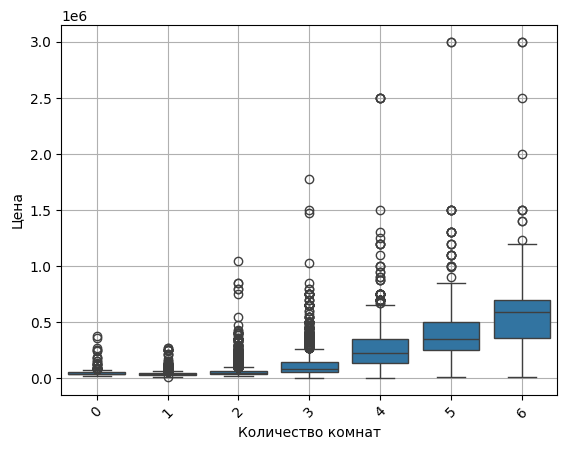

                    count           mean            std      min       25%  \
Количество комнат                                                            
0                   535.0   48481.072897   33423.229858  17500.0   34495.0   
1                  6655.0   41196.689406   15922.699453  12000.0   33000.0   
2                  7407.0   61670.525044   43802.730548  23999.0   42000.0   
3                  3668.0  121904.954471  108828.937781   5000.0   60000.0   
4                  1011.0  275740.840752  234635.597994   5000.0  140000.0   
5                   333.0  430950.504505  340799.281181   8081.0  250000.0   
6                   128.0  642093.742188  495593.955744  10000.0  360000.0   

                        50%       75%        max  
Количество комнат                                 
0                   40000.0   52000.0   380000.0  
1                   38000.0   45000.0   270000.0  
2                   50000.0   65000.0  1050000.0  
3                   80000.0  141250.0  177

In [72]:
sns.boxplot(data=df, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df.groupby('Количество комнат')['Цена'].describe())

In [73]:
print(f"{95}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(95/100)}")
print(f"{5}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(5/100)}")

95% процентиль: Количество комнат
0      80300.0
1      65000.0
2     120000.0
3     310000.0
4     670000.0
5    1100000.0
6    1465000.0
Name: Цена, dtype: float64
5% процентиль: Количество комнат
0     26000.0
1     27000.0
2     35000.0
3     45000.0
4     75000.0
5    116000.0
6     22350.0
Name: Цена, dtype: float64


In [74]:
# отдельно смотрим для 6к кв так как подозрительно низкая цена в 5% процентиле
df_6rooms = df[df['Количество комнат'] == 6]['Цена'].sort_values()
df_6rooms.head(10)

20258     10000
22729     10000
22762     10000
22732     10000
12853     10000
12852     10000
23141     22000
23142     23000
23143     23000
22838    110000
Name: Цена, dtype: int64

In [75]:
# отрезаем выбросы макс/мин 5% сверху и снизу

thresholds = {
    1: (27000, 65000),    # для 1-комнатных: от 27 до 65 тыс
    2: (35000, 120000),   # для 2-комнатных: от 35 до 120 тыс
    3: (45000, 300000),   # для 3-комнатных: от 45 до 300 тыс
    4: (75000, 650000),   # для 4-комнатных: от 75 до 650 тыс
    5: (108500, 750000),  # для 5-комнатных: от 108,5 до 750 тыс
    6: (110000, 1000000)   # для 6-комнатных: от 110 до 1000 тыс 
}

def filter_by_thresholds(row):
    rooms = row['Количество комнат']
    price = row['Цена']
    
    if rooms in thresholds:
        low, high = thresholds[rooms]
        return low <= price <= high
    return True  

# Применяем фильтр
df_filtered = df[df.apply(filter_by_thresholds, axis=1)]

print(f"Было записей: {len(df)}")
print(f"Стало записей: {len(df_filtered)}")
print(f"Удалено: {len(df) - len(df_filtered)}")

Было записей: 19737
Стало записей: 18148
Удалено: 1589


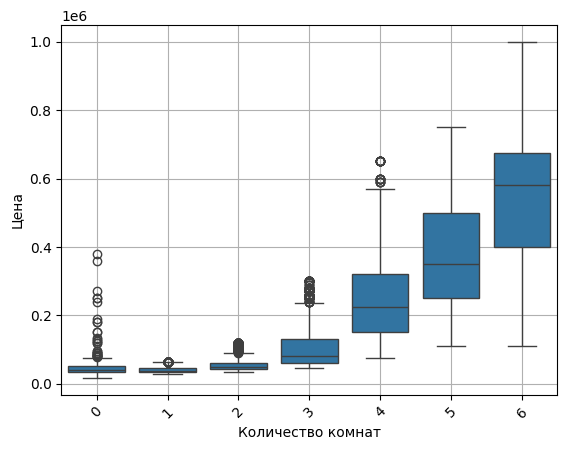

                    count           mean            std       min       25%  \
Количество комнат                                                             
0                   535.0   48481.072897   33423.229858   17500.0   34495.0   
1                  6087.0   39415.703138    8662.581625   27000.0   33000.0   
2                  6835.0   55243.104316   17935.822294   35000.0   43000.0   
3                  3383.0  105129.435117   59173.173176   45000.0   60000.0   
4                   915.0  246204.793443  127596.577627   75000.0  150000.0   
5                   290.0  368393.100000  151730.314879  110000.0  250000.0   
6                   103.0  542951.446602  215603.201784  110000.0  400000.0   

                        50%       75%        max  
Количество комнат                                 
0                   40000.0   52000.0   380000.0  
1                   38000.0   45000.0    65000.0  
2                   50000.0   62000.0   120000.0  
3                   80000.0  1300

In [76]:
# распределение после очистки от выбросов
sns.boxplot(data=df_filtered, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df_filtered.groupby('Количество комнат')['Цена'].describe())

<Axes: >

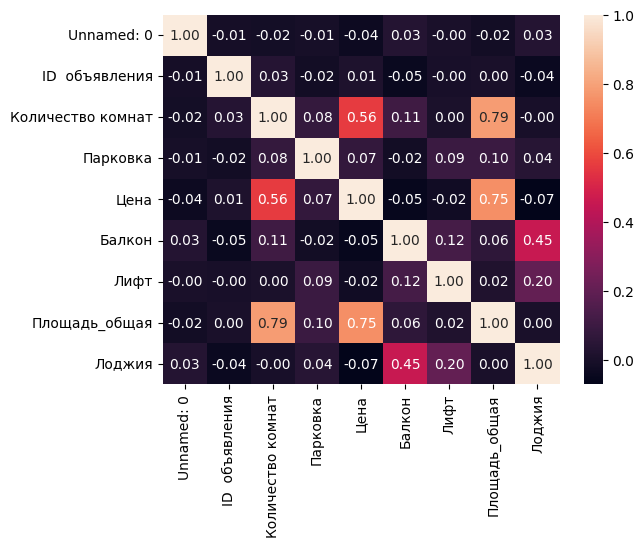

In [77]:
sns.heatmap(df.corr(numeric_only=True), fmt='.2f', annot=True)

In [78]:
df_filtered.columns

Index(['Unnamed: 0', 'ID  объявления', 'Количество комнат', 'Метро', 'Адрес',
       'Парковка', 'Цена', 'Телефоны', 'Описание', 'Ремонт', 'Балкон',
       'Можно с детьми/животными', 'Дополнительно', 'Название ЖК', 'Лифт',
       'Мусоропровод', 'Ссылка на объявление', 'тип_дома', 'этаж_квартиры',
       'этажность_дома', 'Площадь_общая', 'Лоджия'],
      dtype='str')

In [79]:
df_filtered.sample()

,Unnamed: 0,ID объявления,Количество комнат,Метро,Адрес,Парковка,Цена,Телефоны,Описание,Ремонт,...,Дополнительно,Название ЖК,Лифт,Мусоропровод,Ссылка на объявление,тип_дома,этаж_квартиры,этажность_дома,Площадь_общая,Лоджия
7665,7665,274899334,2,м. Юго-Западная (9 мин пешком),"улица 26 Бакинских Комиссаров, 3к3",0,55000,+79651002960,"В благоустроенном районе, в 10 минутах ходьбы ...",NaN,...,"Мебель в комнатах, Душевая кабина, Стиральная ...",NaN,1,NaN,https://www.cian.ru/rent/flat/274899334,Панельный,8,12,50.0,1


In [ ]:
# df.rename(columns ={
#     'ID  объявления': 'id',
#     'Количество комнат': 'number_of_rooms',
#     'Метро': 'subway',
#     'Адрес': 'address',
#     'Парковка': 'parking',
#     'Цена': 'price',
#     'Лифт': 'elevator',
#     'тип_дома': 'type',
#     'этаж_квартиры': 'floor',
#     'этажность_дома': 'number_of_floors',
#     'площадь': 'square',
#     'Ремонт': 'condition',
#     'Балкон': 'balcony',
#     'Лоджия': 'loggia',
#     'Округ': 'county'
# }, inplace=True)

In [ ]:
# сохранение DataFrame
#df.to_csv('data.csv')

In [99]:
df[df['тип_дома'].isna()]
df['тип_дома'].unique()

<StringArray>
[         'Монолитный', 'Монолитно-кирпичный',                   nan,
           'Панельный',          'Сталинский',           'Кирпичный',
         'старый фонд',             'Блочный',          'Деревянный',
             'Щитовой']
Length: 10, dtype: str

In [ ]:
# кодирование через координаты -> результат новая колонка с расстоянием до центра
# def haversine_distance(lat1, lon1, lat2, lon2):
#     # Радиус Земли в километрах
#     r = 6371 
    
#     # Перевод в радианы
#     phi1, phi2 = np.radians(lat1), np.radians(lat2)
#     dphi = np.radians(lat2 - lat1)
#     dlambda = np.radians(lon2 - lon1)
    
#     # Формула гаверсинуса
#     a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
#     res = 2 * r * np.arcsin(np.sqrt(a))
#     return res

# # Координаты центра Москвы (Кремль)
# MOSCOW_CENTER = (55.7522, 37.6175)

# # Создание нового признака
# df['dist_to_center'] = haversine_distance(
#     df['lat'], df['lon'], 
#     MOSCOW_CENTER[0], MOSCOW_CENTER[1]
# )